#Trabalho prático # 1
##Modelagem matemática e Computacional

###Tópico: Força e movimento

---

Nome: Davi dos Santos Mattos

DRE: 119133049


---

**Instruções:**

**Faça uma cópia deste notebook no seu drive, preencha-lo com seus dados, escreva e execute seus códigos antes de entregar o trabalho.**

**Inclua  um relatório, na parte final do notebook,** com suas conclusões, respostas, observações e comentários relacionados às questões abordadas nas tarefas.  

**A elaboração dos códigos pode ser realizada em duplas, mas o resto do trabalho é individual.**

**Não é permitido o uso de IA no desenvolvimento do trabalho.**

*Se você fez o seu trabalho em dupla inclua essa informação no relatório. Além disso, se você  também recebeu ajuda de um(a) colega/amigo(a) ou consultou/usou informações da internet ou outras fontes, coloque referências à elas no seu relatório.*


**Entrega do trabalho:**

*Na entrega do seu trabalho, inclua  o arquivo do seu notebook (.ipynb) diretamente do seu google drive. **Não serão aceitos links para o arquivo**.*

*Data de entrega: 12/junho/2026*

---


A força de atração gravitacional que um corpo de massa $m_1$ exerce no corpo de massa $m_2$ é modelada segundo a lei de gravitação universal de Newton, dada pela equação $$\vec{F}_{12} =  -\frac{Gm_1m_2}{{r}^2}\vec{e}_{12}$$
em que $G$ é a constante de gravitação universal, $r$ a distância entre os corpo e $\vec{e}_{12}$ o vetor unitário direcionado do primeiro para o segundo corpo.

Na modelagem do movimento de corpos celestes no sistema solar é usado o seguinte sistema de unidades fundamentais:

* Comprimento: $1 \,{AU}$ (Unidade Astronômica $\approx$ Distância média Terra-Sol);
* Massa: $1 \,{M}_{\odot}$ (Massa do Sol $\approx 1.98\times 10^{30}\,kg$);
* Tempo: $1\,ano$.

Para a constante de gravitação universal temos que
$$ G = 4\pi^2\;\frac{AU^3}{{M}_{\odot}\times ano^2}.$$


##Tarefa #1:

Implemente um código em Python para simular o movimento do sistema Sol-Terra.

a)  Calcule a evolução do sistema para um período de $2\,\text{anos}$, usando os seguintes dados:


*   Terra:
    1.   Posição inicial: $x_0 = 0.9832\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = 6.2835\,AU/ano$,
    3.   Massa: $m_1 = 3.003\times 10^{-6}\,{M}_{\odot}$
*   Sol:
    1.   Posição inicial: $x_0 = -2.95\times 10^{-6}\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.0\,AU/ano$, $\quad v_{0y} = -1.887\times 10^{-5}\,AU/ano$,
    3.   Massa: $m_2 = 1\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada corpo no plano $XY$, da evolução das coordenadas de cada corpo e da distância entre os dois corpos ao longo do tempo.


---


**Observação**: Use as funcionalidades do [NumPy](https://numpy.org)  para trabalhar com  vetores (*arrays* de dados), do [SciPy](https://scipy.org/) para a resolução de problemas para EDOs (função [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy.integrate.solve_ivp)) e do [MatPlotLib](https://matplotlib.org/) para a visualização dos resultados.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Constante gravitacional em unidades astronômicas
G = 4 * np.pi**2  # AU³ / (M_sol * ano²)

# Planeta Terra
x_terra = [0.9832, 0.0]
v_terra = [0.0, 6.2835]
m_terra = 3.003e-6

# Sol
x_sol = [-2.95e-6, 0.0]
v_sol = [0.0, -1.887e-5]
m_sol = 1.0

In [11]:
def sistema_2corpos(t, y, m1, m2):
    # Desempacotando o vetor de estado
    x1, y1, vx1, vy1 = y[0], y[1], y[2], y[3]
    x2, y2, vx2, vy2 = y[4], y[5], y[6], y[7]

    # Distância entre os corpos
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)

    # Acelerações pela lei de Newton
    ax1 = +G * m2 * dx / r**3
    ay1 = +G * m2 * dy / r**3
    ax2 = -G * m1 * dx / r**3
    ay2 = -G * m1 * dy / r**3

    # Retorna as derivadas na mesma ordem do vetor y
    return [vx1, vy1, ax1, ay1, vx2, vy2, ax2, ay2]

In [12]:
# Massas
m_terra  = 3.003e-6   # M_sol
m_sol    = 1.0        # M_sol

# Vetor de condições iniciais [x1, y1, vx1, vy1, x2, y2, vx2, vy2]
# corpo 1 = Terra, corpo 2 = Sol
y0 = [
    0.9832,   0.0,    0.0,       6.2835,     # Terra
   -2.95e-6,  0.0,   0.0,      -1.887e-5    # Sol
]

# Intervalo de tempo
t_span = (0, 2)                        # 2 anos
t_eval = np.linspace(0, 2, 10000)     # pontos para salvar

# Resolvendo
sol = solve_ivp(
    fun=lambda t, y: sistema_2corpos(t, y, m_terra, m_sol),
    t_span=t_span,
    y0=y0,
    t_eval=t_eval,
    method='RK45',
    rtol=1e-9,
    atol=1e-9
)

In [13]:
# Extraindo as soluções
x_terra  = sol.y[0]
y_terra  = sol.y[1]
x_sol    = sol.y[4]
y_sol    = sol.y[5]
t        = sol.t

# Distância entre os corpos ao longo do tempo
r = np.sqrt((x_terra - x_sol)**2 + (y_terra - y_sol)**2)

In [14]:
# Posições finais (último instante de tempo)
print("=== Posições finais após 2 anos ===\n")
print(f"Terra: x = {x_terra[-1]:.6f} AU,  y = {y_terra[-1]:.6f} AU")
print(f"Sol:   x = {x_sol[-1]:.6f} AU,  y = {y_sol[-1]:.6f} AU")

=== Posições finais após 2 anos ===

Terra: x = 0.793185 AU,  y = 0.575597 AU
Sol:   x = -0.000002 AU,  y = -0.000002 AU


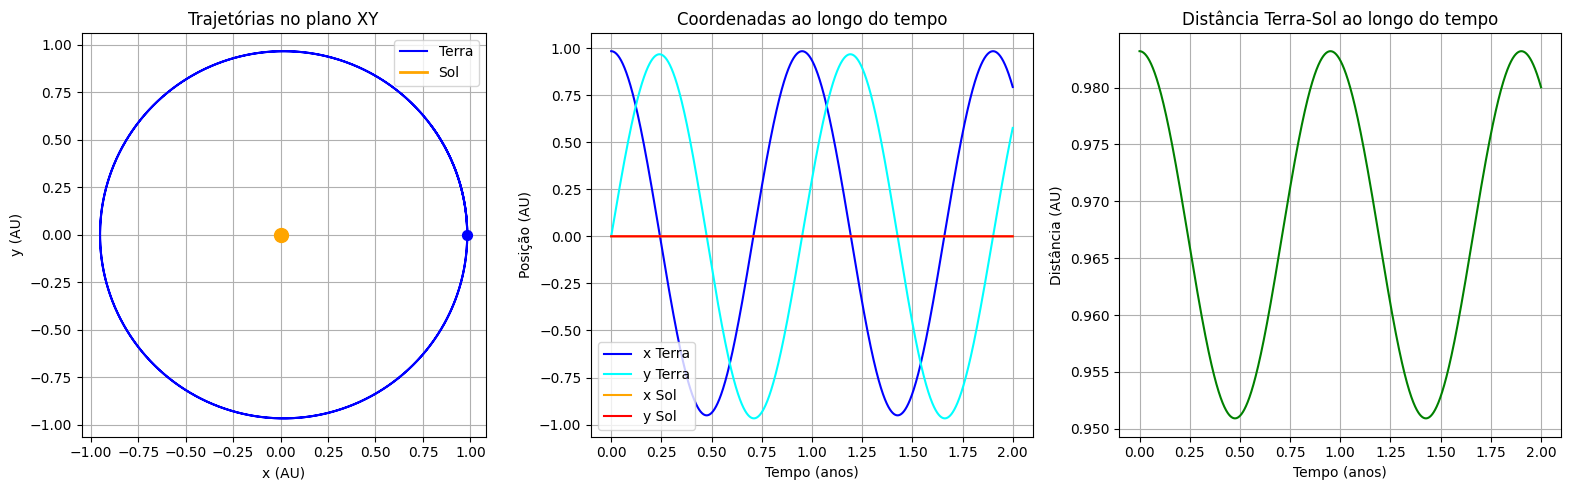

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

# --- Gráfico 1: Trajetórias no plano XY ---
axs[0].plot(x_terra, y_terra, label='Terra', color='blue')
axs[0].plot(x_sol,   y_sol,   label='Sol',   color='orange', linewidth=2)
axs[0].scatter(*[x_terra[0], y_terra[0]], color='blue',   s=50, zorder=5)
axs[0].scatter(*[x_sol[0],   y_sol[0]],   color='orange', s=100, zorder=5)
axs[0].set_xlabel('x (AU)')
axs[0].set_ylabel('y (AU)')
axs[0].set_title('Trajetórias no plano XY')
axs[0].legend()
axs[0].set_aspect('equal')
axs[0].grid(True)

# --- Gráfico 2: Coordenadas ao longo do tempo ---
axs[1].plot(t, x_terra, label='x Terra', color='blue')
axs[1].plot(t, y_terra, label='y Terra', color='cyan')
axs[1].plot(t, x_sol,   label='x Sol',   color='orange')
axs[1].plot(t, y_sol,   label='y Sol',   color='red')
axs[1].set_xlabel('Tempo (anos)')
axs[1].set_ylabel('Posição (AU)')
axs[1].set_title('Coordenadas ao longo do tempo')
axs[1].legend()
axs[1].grid(True)

# --- Gráfico 3: Distância entre os corpos ---
axs[2].plot(t, r, color='green')
axs[2].set_xlabel('Tempo (anos)')
axs[2].set_ylabel('Distância (AU)')
axs[2].set_title('Distância Terra-Sol ao longo do tempo')
axs[2].grid(True)

plt.tight_layout()
plt.show()

##Tarefa #2:

Implemente um código em Python para simular a evolução de um sistema de três estrelas.

a)  Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.466203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$


b) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

c) Calcule a evolução do sistema para um período de $10.5\,anos$. Use os seguintes dados:

*   Estrela 1:
    1.   Posição inicial: $x_0 = 0.970043\,AU$, $\quad y_0 = -0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.166203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_1 = 0.02533/(4\pi^2)\,{M}_{\odot}$
*   Estrela 2:
    1.   Posição inicial: $x_0 = -0.970043\,AU$, $\quad y_0 = 0.243087\,AU$,
    2.   Velocidade inicial: $v_{0x} = 0.766203\,AU/ano$, $\quad v_{0y} = 0.432365\,AU/ano$,
    3.   Massa: $m_2 = 0.02533\,{M}_{\odot}$
*   Estrela 3:
    1.   Posição inicial: $x_0 = 0.0\,AU$, $\quad y_0 = 0.0\,AU$,
    2.   Velocidade inicial: $v_{0x} = -0.932406\,AU/ano$, $\quad v_{0y} = -0.864730\,AU/ano$,
    3.   Massa: $m_3 = 0.02533\,{M}_{\odot}$

d) Mostre os gráficos das trajetórias de cada estrela no plano $XY$, da evolução das coordenadas de cada estrela e das distâncias mutuas entre as estrelas ao longo do tempo.

e) Descreva qualitativamente os movimentos do sistema calculados nos itens a) e c). Indique semelhanças e diferenças entre esses dois cenários.

In [16]:
# Adicione aqui seus códigos, mostrando os resultados pedidos

## Relatório

*(Escreva aqui seu relatório.)*